In [ ]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# ==========================================
# 1. TRIỂN KHAI SVM (LINEAR SVM - SCRATCH)
# ==========================================
class SVM_Scratch:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, iterations=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param # Tham số điều chuẩn (Regularization)
        self.iterations = iterations
        self.w = None
        self.b = None

    def fit(self, X, y):
        # SVM yêu cầu nhãn là {1, -1} thay vì {1, 0}
        y_transformed = np.where(y <= 0, -1, 1)
        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.iterations):
            for idx, x_i in enumerate(X):
                # Điều kiện Hinge Loss: y_i * (w * x_i - b) >= 1
                condition = y_transformed[idx] * (np.dot(x_i, self.w) - self.b) >= 1

                if condition:
                    # Chỉ cập nhật đạo hàm của phần điều chuẩn (Regularization)
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Cập nhật cả phần sai số và điều chuẩn
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_transformed[idx]))
                    self.b -= self.lr * y_transformed[idx]

            if i % 200 == 0:
                print(f"Vòng lặp SVM {i}...")

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.where(approx >= 0, 1, 0)

# ==========================================
# 2. CHUẨN BỊ DỮ LIỆU (8:2, 35% SPAM TRONG TRAIN)
# ==========================================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Spam Mail/spam_ham_dataset.csv')
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

# Tách tập Test gốc (20%)
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Lọc tập Train để có 35% Spam
df_spam_train = df_train_full[df_train_full['label_num'] == 1]
df_ham_train = df_train_full[df_train_full['label_num'] == 0]

n_spam = len(df_spam_train)
n_ham_needed = int((n_spam / 0.35) - n_spam)
df_ham_train_down = df_ham_train.sample(n=min(n_ham_needed, len(df_ham_train)), random_state=42)

df_train_final = pd.concat([df_spam_train, df_ham_train_down]).sample(frac=1, random_state=42)

X_train_raw = df_train_final['text'].astype(str).values
y_train = df_train_final['label_num'].values

# ==========================================
# 3. VECTOR HÓA VÀ HUẤN LUYỆN
# ==========================================
vectorizer = TfidfVectorizer(max_features=2500)
X_train = vectorizer.fit_transform(X_train_raw).toarray()

# Khởi tạo và huấn luyện SVM
model = SVM_Scratch(learning_rate=0.001, lambda_param=0.01, iterations=500)
model.fit(X_train, y_train)

# ==========================================
# 4. LƯU MÔ HÌNH
# ==========================================
model_save = {
    'w': model.w,
    'b': model.b,
    'vocabulary': vectorizer.vocabulary_,
    'idf': vectorizer.idf_
}

with open("svm_scratch_model.pkl", "wb") as f:
    pickle.dump(model_save, f)

print("Đã xuất mô hình SVM thành công!")

Vòng lặp SVM 0...
Vòng lặp SVM 200...
Vòng lặp SVM 400...
Đã xuất mô hình SVM thành công!



--- KẾT QUẢ ĐÁNH GIÁ SVM (SCRATCH) ---
Độ chính xác trên tập Test: 73.62%

Báo cáo chi tiết:
              precision    recall  f1-score   support

         Ham       0.73      1.00      0.84       742
        Spam       1.00      0.07      0.13       293

    accuracy                           0.74      1035
   macro avg       0.87      0.53      0.49      1035
weighted avg       0.81      0.74      0.64      1035



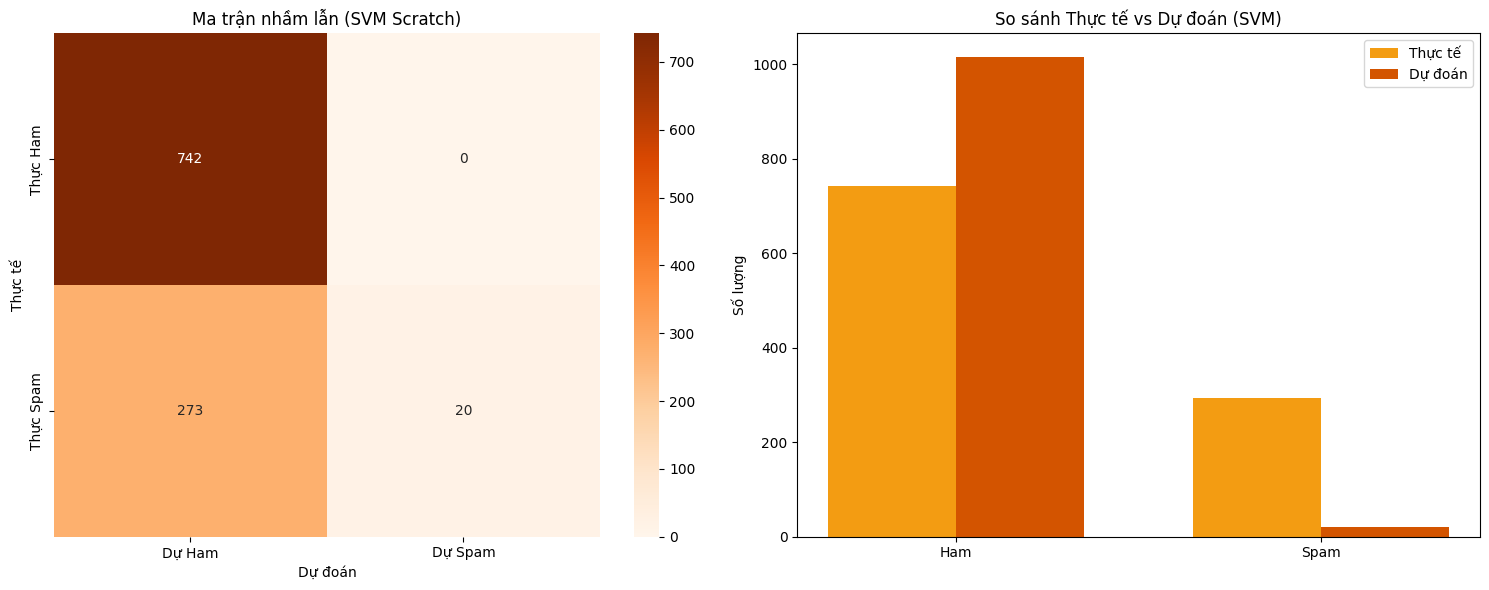

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ==========================================
# 1. ĐƯỜNG DẪN FILE
# ==========================================
PATH_MODEL_PKL = '/content/drive/MyDrive/Colab Notebooks/Spam Mail/svm_scratch_model.pkl'
PATH_DATA_CSV = '/content/drive/MyDrive/Colab Notebooks/Spam Mail/spam_ham_dataset.csv'

# ==========================================
# 2. LOAD MODEL VÀ DỮ LIỆU GỐC
# ==========================================
with open(PATH_MODEL_PKL, 'rb') as f:
    model_data = pickle.load(f)

# Lấy các tham số của SVM
w = model_data['w']
b = model_data['b']
vocab = model_data['vocabulary']
saved_idf = model_data['idf']

# Load dữ liệu gốc để tách tập Test (20%)
df = pd.read_csv(PATH_DATA_CSV)
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})
X_text = df['text'].astype(str).values
y = df['label_num'].values

# Đảm bảo random_state=42 để lấy đúng tập Test chưa qua xử lý Train
_, X_test_raw, _, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# ==========================================
# 3. VECTOR HÓA VÀ DỰ ĐOÁN (SVM LOGIC)
# ==========================================
vectorizer = TfidfVectorizer(vocabulary=vocab)
vectorizer.idf_ = saved_idf
X_test = vectorizer.transform(X_test_raw).toarray()

def predict_svm(X, w, b):
    # Công thức dự đoán SVM: f(x) = w*x - b
    approx = np.dot(X, w) - b
    # Nếu approx >= 0 trả về 1 (Spam), ngược lại 0 (Ham)
    return np.where(approx >= 0, 1, 0)

# Chạy dự đoán
y_pred = predict_svm(X_test, w, b)

# ==========================================
# 4. ĐÁNH GIÁ VÀ VẼ BIỂU ĐỒ
# ==========================================
acc = accuracy_score(y_test, y_pred)
print(f"\n--- KẾT QUẢ ĐÁNH GIÁ SVM (SCRATCH) ---")
print(f"Độ chính xác trên tập Test: {acc*100:.2f}%")
print("\nBáo cáo chi tiết:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# VẼ BIỂU ĐỒ
plt.figure(figsize=(15, 6))

# 1. Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Dự Ham', 'Dự Spam'], yticklabels=['Thực Ham', 'Thực Spam'])
plt.title('Ma trận nhầm lẫn (SVM Scratch)')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')

# 2. Bar Chart so sánh
plt.subplot(1, 2, 2)
labels = ['Ham', 'Spam']
actual = [np.sum(y_test == 0), np.sum(y_test == 1)]
predicted = [np.sum(y_pred == 0), np.sum(y_pred == 1)]

x = np.arange(len(labels))
width = 0.35
plt.bar(x - width/2, actual, width, label='Thực tế', color='#f39c12')
plt.bar(x + width/2, predicted, width, label='Dự đoán', color='#d35400')
plt.xticks(x, labels)
plt.ylabel('Số lượng')
plt.title('So sánh Thực tế vs Dự đoán (SVM)')
plt.legend()

plt.tight_layout()
plt.show()